In [1]:
import numpy as np
import matplotlib.pyplot as plt
import glob
from pathlib import Path
import h5py

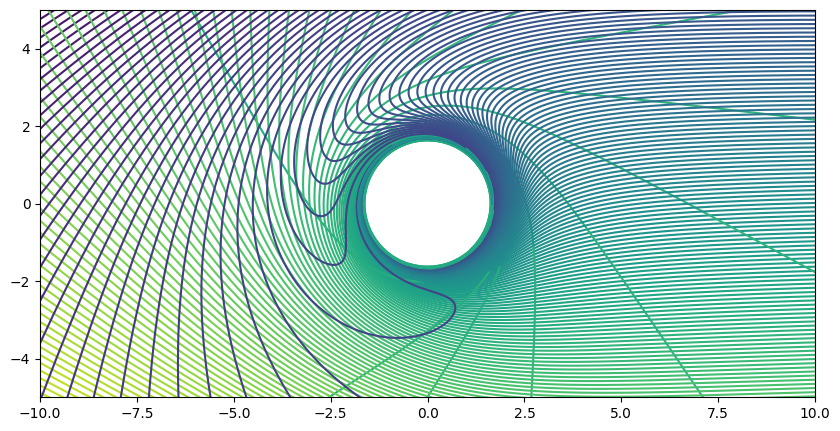

In [25]:
fig = plt.figure(figsize=(10, 10))
cmap = plt.get_cmap("viridis")
with h5py.File(
    "/Users/nilsvu/Projects/spectre/build-Default-Release/RayTraces0.h5", "r"
) as open_h5file:
    ray_traces = open_h5file["RayTraces"]["Frame0"]
    num_rays = len(ray_traces)
    for name, data in ray_traces.items():
        ray_index = int(name[3:-4])
        plt.plot(data[:, 0], data[:, 1], color=cmap(ray_index / (num_rays - 1)))
plt.xlim(-10, 10)
plt.ylim(-5, 5)
plt.gca().set_aspect("equal")

---

older plots

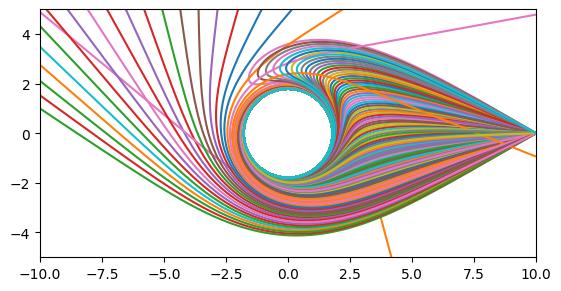

In [ ]:
# circle = plt.Circle((0, 0), 2, color="black", fill=True, lw=0)
# plt.gca().add_artist(circle)
for fname in glob.glob(
    "/Users/nilsvu/Projects/spectre/build-Default-Debug/ray_*.dat"
):
    data = np.loadtxt(fname)
    plt.plot(data[:, 1], data[:, 2])
plt.xlim(-10, 10)
plt.ylim(-5, 5)
plt.gca().set_aspect("equal")

(np.float64(-47.8902),
 np.float64(89.55919999999999),
 np.float64(-64.655485),
 np.float64(97.55898499999999))

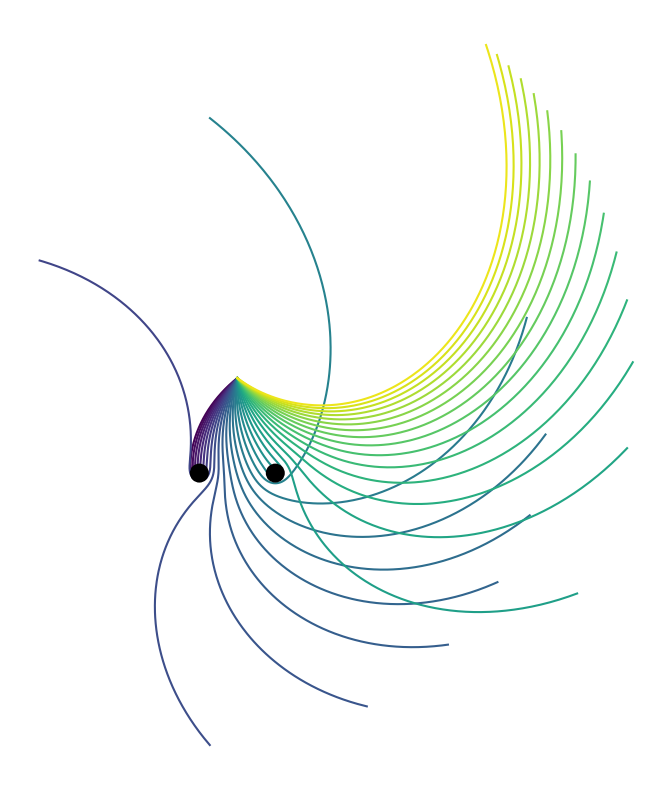

In [30]:
plt.figure(figsize=(10, 10))
ray_files = sorted(
    glob.glob("/Users/nilsvu/Projects/spectre/build-Default-Debug/ray_*.dat"),
    key=lambda x: int(x.split("/")[-1].split("_")[1].split(".")[0]),
)[::3]
cmap = plt.get_cmap("viridis")
for i, fname in enumerate(ray_files):
    data = np.loadtxt(fname)
    plt.plot(data[:, 1], data[:, 2], color=cmap(i / len(ray_files)))
# plt.xlim(-10, 10)
# plt.ylim(-5, 5)
plt.gca().set_aspect("equal")
plt.gca().add_artist(
    plt.Circle((8, 0), 2, color="black", fill=True, lw=0, zorder=30)
)
plt.gca().add_artist(
    plt.Circle((-8, 0), 2, color="black", fill=True, lw=0, zorder=30)
)
plt.axis('off')

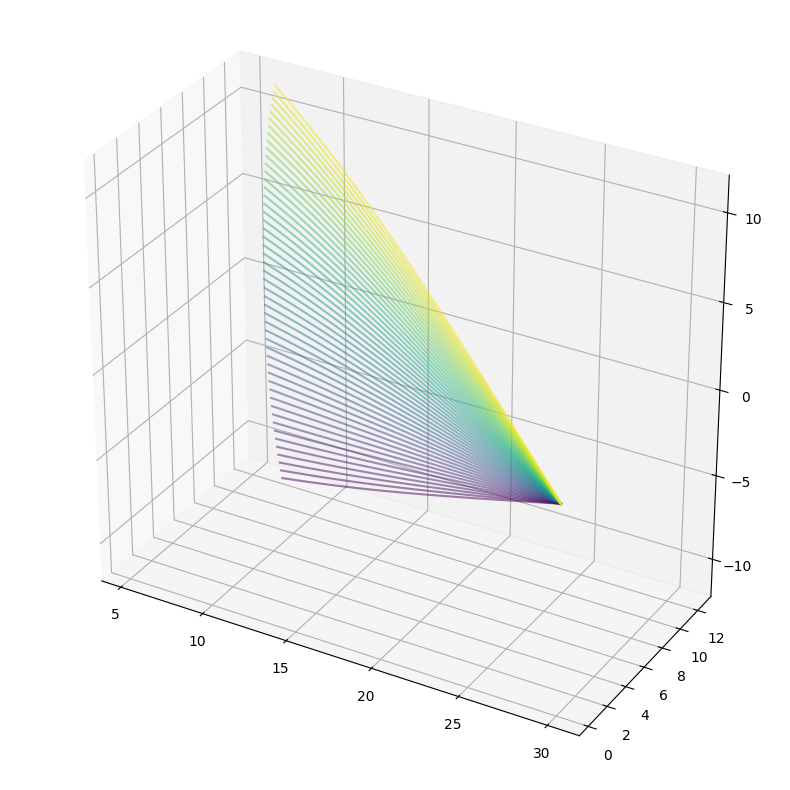

In [68]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
cmap = plt.get_cmap("viridis")
filename = "/Users/nilsvu/Projects/spectre/build-Default-Debug/RayTraces.h5"
with h5py.File(filename, "r") as open_h5file:
    ray_traces = open_h5file["RayTraces"]
    num_rays = len(ray_traces)
    for name, data in ray_traces.items():
        ray_index = int(name[3:-4])
        if ray_index % 200 != 0:
            continue
        ax.plot(data[:, 0], data[:, 1], data[:, 2], color=cmap(ray_index / (num_rays - 1)), alpha=0.5)
# plt.xlim(-10, 10)
# plt.ylim(-5, 5)
plt.gca().set_aspect("equal")
# plt.gca().add_artist(
#     plt.Circle((8, 0), 2, color="black", fill=True, lw=0, zorder=30)
# )
# plt.gca().add_artist(
#     plt.Circle((-8, 0), 2, color="black", fill=True, lw=0, zorder=30)
# )
# plt.axis("off")

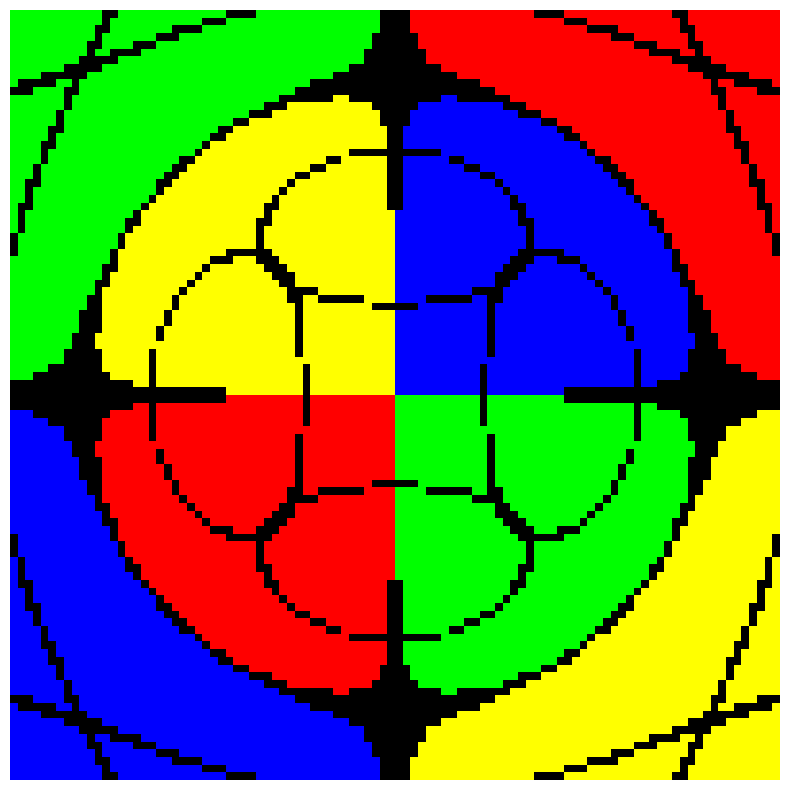

In [4]:
plt.figure(figsize=(10, 10))
# cmap = plt.get_cmap("viridis")
# cmap.set_bad("black", 1.0)
filename = "/Users/nilsvu/Projects/spectre/build-Default-Debug/RayTraces0.h5"
with h5py.File(filename, "r") as open_h5file:
    resolution = (100, 100)
    frame_data = open_h5file["Camera/Frame0.dat"][:]
x, y, z = frame_data[:, :3].T
r = np.sqrt(x**2 + y**2 + z**2)
theta = np.arctan2(np.sqrt(x**2 + y**2), z)  # [0, pi]
phi = np.arctan2(y, x) + np.pi  # [0, 2pi]
horizon_mask = r == 0
theta[horizon_mask] = np.nan
phi[horizon_mask] = np.nan

num_rings_theta = 10
num_rings_phi = 2 * num_rings_theta
ring_width = 0.01
segment_width_phi = 2 * np.pi / num_rings_phi
segment_width_theta = np.pi / num_rings_theta
mod_phi = phi % segment_width_phi
mod_theta = theta % segment_width_theta

image = np.zeros((len(phi), 3))
image[(theta < np.pi / 2) & (phi < np.pi), 0] = 1
image[(theta < np.pi / 2) & (phi >= np.pi), 1] = 1
image[(theta >= np.pi / 2) & (phi < np.pi), 0] = 1
image[(theta >= np.pi / 2) & (phi < np.pi), 1] = 1
image[(theta >= np.pi / 2) & (phi >= np.pi), 2] = 1
image[
    (mod_phi <= ring_width)
    | (mod_phi >= segment_width_phi - ring_width)
    | (mod_theta <= ring_width)
    | (mod_theta >= segment_width_theta - ring_width),
    :,
] = 0
image[horizon_mask, :] = 0

plt.axis("off")
plt.imshow(
    image.reshape(resolution + (3,)), origin="lower", interpolation="nearest"
)

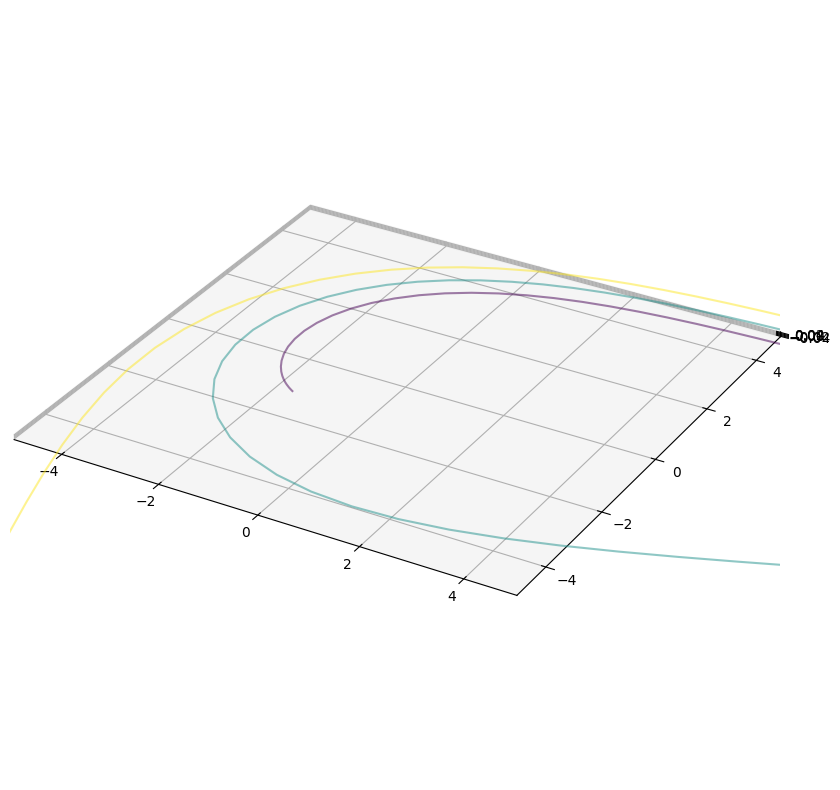

In [24]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection="3d")
cmap = plt.get_cmap("viridis")
filename = "/Users/nilsvu/Projects/spectre/build-Default-Debug/RayTracerTest.h5"
with h5py.File(filename, "r") as open_h5file:
    ray_traces = open_h5file["RayTraces/Frame0"]
    num_rays = len(ray_traces)
    for name, data in ray_traces.items():
        ray_index = int(name[3:-4])
        # if ray_index % 200 != 0:
        #     continue
        ax.plot(
            data[:, 0],
            data[:, 1],
            data[:, 2],
            color=cmap(ray_index / (num_rays - 1)),
            alpha=0.5,
        )
plt.xlim(-5, 5)
plt.ylim(-5, 5)
plt.gca().set_aspect("equal")
# plt.gca().add_artist(
#     plt.Circle((8, 0), 2, color="black", fill=True, lw=0, zorder=30)
# )
# plt.gca().add_artist(
#     plt.Circle((-8, 0), 2, color="black", fill=True, lw=0, zorder=30)
# )
# plt.axis("off")